In [30]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import fsolve, least_squares
from contextlib import contextmanager
from io import StringIO

sys.path.append('..') # location of EquiNet repository

from equinet.train import make_predictions, load_model
from equinet.args import PredictArgs

In [31]:
# set your inputs
smiles1 = "c1ccccc1" # Cyclohexane
smiles2 = "CCN(CC)CC" # Triethylamine
P_target = 101325  # Pressure in Pa
n = 101 # Mesh size of mole fractions
model_path = "../equinet/pretrained_models/equinet_v0.2.0.pt" # Directory containing the trained .pt file

In [32]:
# If you want a temporary path location for the results to write to
import tempfile

temp_preds = tempfile.mktemp(suffix='.csv')
temp_features = tempfile.mktemp(suffix='.csv')
temp_test = tempfile.mktemp(suffix='.csv')

In [33]:
# context class to suppress print statements from repeated model predictions

class NoPrint:
    """
    Context manager to suppress print statements.
    """
    def __enter__(self):
        self._original_stdout = sys.stdout
        self._original_sterr = sys.stderr
        sys.stdout = StringIO()
        sys.stderr = StringIO()

    def __exit__(self, exc_type, exc_value, traceback):
        sys.stdout = self._original_stdout
        sys.stderr = self._original_sterr


In [34]:
# Finding the pure component vapor pressures over a range of temperatures

logP_target = np.log10(P_target)
print("logP_target", logP_target)

# make input files
x1s = np.full(701, 0.5)
x2s = np.full(701, 0.5)
Ts = np.linspace(100, 800, 701)

test_df = pd.DataFrame({
    'smiles1': [smiles1] * 701,
    'smiles2': [smiles2] * 701,
})
features_df = pd.DataFrame({
    'x1': x1s,
    'x2': x2s,
    'T': Ts,
    'log10P1sat': ["nan"] * 701,
    'log10P2sat': ["nan"] * 701,
})

test_df.to_csv(temp_test, index=False)
features_df.to_csv(temp_features, index=False)

# make predictions

arguments = [
    '--test_path', temp_test,
    '--features_path', temp_features,
    '--preds_path', temp_preds,
    '--checkpoint_path', model_path,
    '--number_of_molecules', '2',
    '--num_workers', '0',
]

args = PredictArgs().parse_args(arguments)

model_objects = load_model(args=args)

with NoPrint():
    preds = np.array(make_predictions(args=args, model_objects=model_objects)) # output: [y1,y2,log10P,lngamma1,lngamma2,log10P1sat,log10P2sat]

logP_target 5.005716612413731
Loading training args
Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "encoder.encoder.1.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.1.W_i.weight".
Loading pretrained parameter "encoder.encoder.1.W_h.weight".
Loading pretrained parameter "encoder.encoder.1.W_o.weight".
Loading pretrained parameter "encoder.encoder.1.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".
Loading pretrained parameter "intrinsic_vp.1.weight".
Loading pretrained parameter "intrinsic_vp.1.bias".
Loading pretrained parameter

In [35]:
# Finding T closest to the target pressure for each component
logP1sats = preds[:, 5]
logP2sats = preds[:, 6]

closest_P1_index = np.argmin(np.abs(logP1sats - logP_target))
closest_P2_index = np.argmin(np.abs(logP2sats - logP_target))

closest_P1_T = Ts[closest_P1_index]
closest_P2_T = Ts[closest_P2_index]

print("closest P1", logP1sats[closest_P1_index], "at T =", closest_P1_T)
print("closest P2", logP2sats[closest_P2_index], "at T =", closest_P2_T)


closest P1 5.000494003295898 at T = 353.0
closest P2 5.009513854980469 at T = 363.0


In [36]:
# Set up a prediction function to optimize around
counter = 1

def predict_P(T):
    global counter
    global preds

    print(f"iteration {counter}")
    counter += 1
    print("predict_P called with T =", T)
    
    test_df = pd.DataFrame({
        'smiles1': [smiles1]*n,
        'smiles2': [smiles2]*n,
    })
    features_df = pd.DataFrame({
        'x1': np.linspace(0, 1, n),
        'x2': np.linspace(1, 0, n),
        'T': T, # T is a list of temperatures 
        'log10P1sat': ["nan"]*n,
        'log10P2sat': ["nan"]*n,
    })
    test_df.to_csv(temp_test, index=False)
    features_df.to_csv(temp_features, index=False)

    args = PredictArgs().parse_args([
        '--test_path', temp_test,
        '--features_path', temp_features,
        '--preds_path', temp_preds,
        '--checkpoint_path', model_path,
        '--number_of_molecules', '2',
        '--num_workers', '0',
    ])

    with NoPrint():
        preds = np.array(make_predictions(args=args, model_objects=model_objects))  # [y1,y2,log10P,lngamma1,lngamma2,log10P1sat,log10P2sat]
        P_preds = 10 ** preds[:, 2]
    print("preds", P_preds)
    return P_preds - P_target

In [37]:
# Assumes linear interpolation between pure component temperatures
T_guess = np.linspace(closest_P2_T, closest_P1_T, n)
T_guess

array([363. , 362.9, 362.8, 362.7, 362.6, 362.5, 362.4, 362.3, 362.2,
       362.1, 362. , 361.9, 361.8, 361.7, 361.6, 361.5, 361.4, 361.3,
       361.2, 361.1, 361. , 360.9, 360.8, 360.7, 360.6, 360.5, 360.4,
       360.3, 360.2, 360.1, 360. , 359.9, 359.8, 359.7, 359.6, 359.5,
       359.4, 359.3, 359.2, 359.1, 359. , 358.9, 358.8, 358.7, 358.6,
       358.5, 358.4, 358.3, 358.2, 358.1, 358. , 357.9, 357.8, 357.7,
       357.6, 357.5, 357.4, 357.3, 357.2, 357.1, 357. , 356.9, 356.8,
       356.7, 356.6, 356.5, 356.4, 356.3, 356.2, 356.1, 356. , 355.9,
       355.8, 355.7, 355.6, 355.5, 355.4, 355.3, 355.2, 355.1, 355. ,
       354.9, 354.8, 354.7, 354.6, 354.5, 354.4, 354.3, 354.2, 354.1,
       354. , 353.9, 353.8, 353.7, 353.6, 353.5, 353.4, 353.3, 353.2,
       353.1, 353. ])

In [38]:
# optimize using scipy. Sparsity indicates that each temperature only affects its own prediction.

T_solution = least_squares(predict_P, T_guess, diff_step=1e-4, jac_sparsity=np.identity(n))

iteration 1
predict_P called with T = [363.  362.9 362.8 362.7 362.6 362.5 362.4 362.3 362.2 362.1 362.  361.9
 361.8 361.7 361.6 361.5 361.4 361.3 361.2 361.1 361.  360.9 360.8 360.7
 360.6 360.5 360.4 360.3 360.2 360.1 360.  359.9 359.8 359.7 359.6 359.5
 359.4 359.3 359.2 359.1 359.  358.9 358.8 358.7 358.6 358.5 358.4 358.3
 358.2 358.1 358.  357.9 357.8 357.7 357.6 357.5 357.4 357.3 357.2 357.1
 357.  356.9 356.8 356.7 356.6 356.5 356.4 356.3 356.2 356.1 356.  355.9
 355.8 355.7 355.6 355.5 355.4 355.3 355.2 355.1 355.  354.9 354.8 354.7
 354.6 354.5 354.4 354.3 354.2 354.1 354.  353.9 353.8 353.7 353.6 353.5
 353.4 353.3 353.2 353.1 353. ]
preds [102214.81689283 102420.62475437 102623.91736898 102824.67812608
 103023.45617508 103217.97190268 103408.31327035 103596.04825177
 103780.81954549 103959.52817638 104134.19971989 104305.84351151
 104474.32891273 104639.86949378 104803.25588629 104963.32472675
 105120.0600436  105272.86825423 105422.07880799 105567.67578564
 105708.599061 

In [39]:
T = T_solution.x
T

array([362.67994065, 362.50741407, 362.33748748, 362.16875163,
       362.00381807, 361.83995855, 361.67704744, 361.5146497 ,
       361.35354215, 361.19376452, 361.03542941, 360.87879643,
       360.72344332, 360.56917812, 360.41566793, 360.26323348,
       360.1119351 , 359.96177779, 359.81190862, 359.66392791,
       359.51655945, 359.37051996, 359.22607365, 359.08317438,
       358.94180933, 358.80209869, 358.66425111, 358.5279613 ,
       358.39315577, 358.25976264, 358.12789803, 357.99762526,
       357.86906632, 357.74199658, 357.61647451, 357.49234841,
       357.37002822, 357.24968893, 357.13127546, 357.01481027,
       356.90056329, 356.78858919, 356.67817323, 356.56940618,
       356.46238155, 356.3568202 , 356.25259463, 356.1499792 ,
       356.04895699, 355.9495371 , 355.85176036, 355.75559041,
       355.66104589, 355.56812642, 355.47705077, 355.38789062,
       355.30036965, 355.2145099 , 355.13029946, 355.04777576,
       354.96694903, 354.88795648, 354.81075479, 354.73

In [40]:
T_solution.fun # residuals from the target pressure, in Pa

array([ 0.04392657, -0.06732403, -0.06732403,  0.04392657, -0.06732403,
        0.04392657, -0.06732403, -0.06732403,  0.04392657, -0.06732403,
        0.04392657,  0.04392657,  0.04392657, -0.06732403,  0.04392657,
       -0.06732403,  0.04392657, -0.06732403,  0.04392657, -0.06732403,
        0.04392657,  0.04392657,  0.04392657,  0.04392657,  0.04392657,
       -0.06732403,  0.04392657, -0.06732403,  0.04392657, -0.06732403,
        0.04392657,  0.04392657,  0.04392657, -0.06732403,  0.04392657,
        0.04392657,  0.04392657,  0.04392657,  0.04392657,  0.04392657,
        0.04392657,  0.04392657, -0.06732403,  0.04392657,  0.04392657,
        0.04392657, -0.06732403, -0.06732403,  0.04392657, -0.06732403,
        0.04392657,  0.04392657,  0.04392657,  0.04392657,  0.04392657,
       -0.06732403, -0.06732403,  0.04392657,  0.04392657,  0.04392657,
        0.04392657, -0.06732403, -0.06732403,  0.04392657, -0.06732403,
        0.04392657,  0.04392657,  0.04392657,  0.04392657, -0.06

Text(0.5, 1.0, 'Mixture of SMILES c1ccccc1 (1) and \nSMILES CCN(CC)CC (2) at P = 101325 Pa')

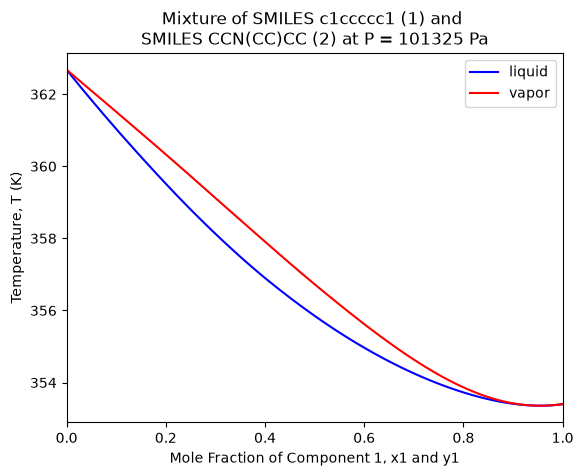

In [41]:
# Recover compositions from the global preds variable
# To avoid use of global variables, re-predict using the optimized temperatures

x1s = np.linspace(0, 1, n)
y1s = preds[:, 0]


plt.plot(x1s, T,label="liquid", color='blue')
plt.plot(y1s, T, label="vapor", color='red')
plt.legend()
plt.xlim(0, 1)
plt.ylabel('Temperature, T (K)')
plt.xlabel('Mole Fraction of Component 1, x1 and y1')
plt.title(f'Mixture of SMILES {smiles1} (1) and \nSMILES {smiles2} (2) at P = {P_target} Pa')